In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [40]:
df = pd.read_csv("../data/Telco_customer_churn.csv")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [41]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [42]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [43]:
df['Churn Label'].value_counts(normalize=True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

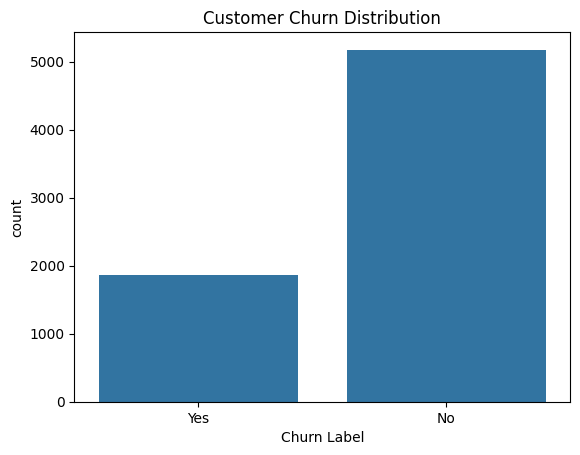

In [44]:
sns.countplot(x='Churn Label', data=df)

plt.title("Customer Churn Distribution")
plt.show()

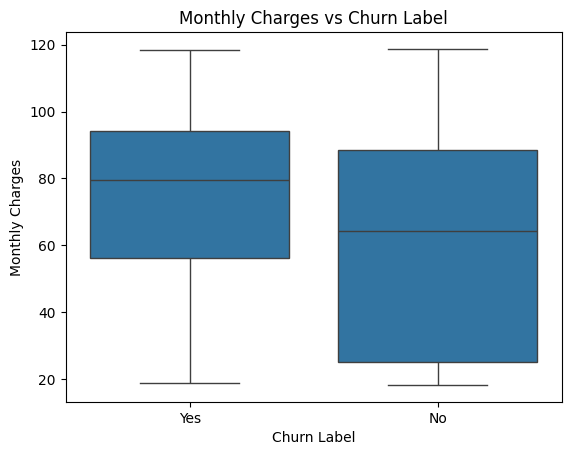

In [45]:
sns.boxplot(x='Churn Label', y='Monthly Charges', data=df)

plt.title("Monthly Charges vs Churn Label")
plt.show()

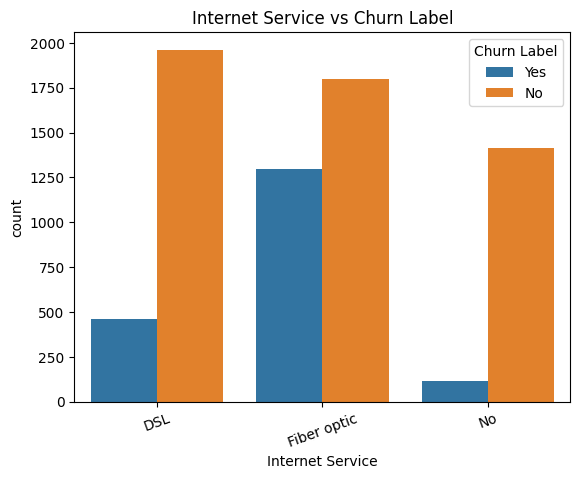

In [46]:
sns.countplot(x='Internet Service', hue='Churn Label', data=df)

plt.xticks(rotation=20)
plt.title("Internet Service vs Churn Label")
plt.show()

In [47]:
drop_cols = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'City',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Reason',
    'Churn Score',
    'Churn Value',
    'Churn Category',
    'Customer Status'
]

In [48]:
X = df.drop(columns=drop_cols + ['Churn Label'], errors='ignore')
y = df['Churn Label']

# One-Hot Encoding BEFORE split
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [49]:
from sklearn.preprocessing import StandardScaler

feature_names = X_train.columns

scaler = StandardScaler()

X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names)
X_test = pd.DataFrame(scaler.transform(X_test), columns=feature_names)

In [50]:
# Convert target if it's currently strings
y_train = y_train.map({'Yes': 1, 'No': 0})
y_test = y_test.map({'Yes': 1, 'No': 0})

In [51]:
# Train the model
lr = LogisticRegression(max_iter=2000)

lr.fit(X_train, y_train)

#Prediction
pred = lr.predict(X_test)

In [52]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, pred))

0.7757274662881476


In [53]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [54]:
from sklearn.metrics import accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))

Random Forest Accuracy: 0.7991483321504613


In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1009
           1       0.70      0.51      0.59       400

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



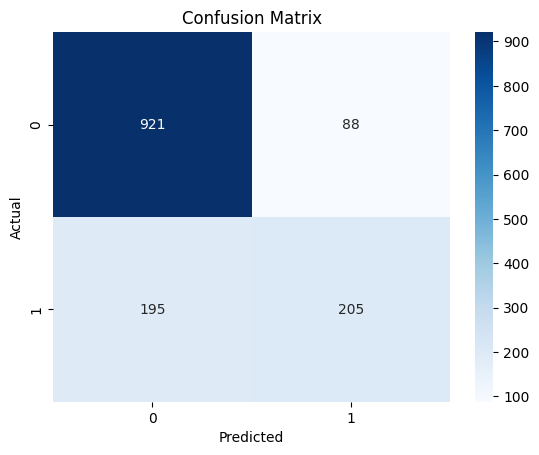

In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [57]:
feature_names = rf.feature_names_in_ 
importance = rf.feature_importances_

# Create the DataFrame
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# Sort and Display
feature_df = feature_df.sort_values(by='Importance', ascending=False)
print(feature_df.head(10))

                            Feature  Importance
0                     Tenure Months    0.107135
1                   Monthly Charges    0.081681
2                              CLTV    0.077513
25                Contract_Two year    0.026089
28  Payment Method_Electronic check    0.024137
6                    Dependents_Yes    0.023949
10     Internet Service_Fiber optic    0.022892
13              Online Security_Yes    0.020731
19                 Tech Support_Yes    0.020116
26            Paperless Billing_Yes    0.018710


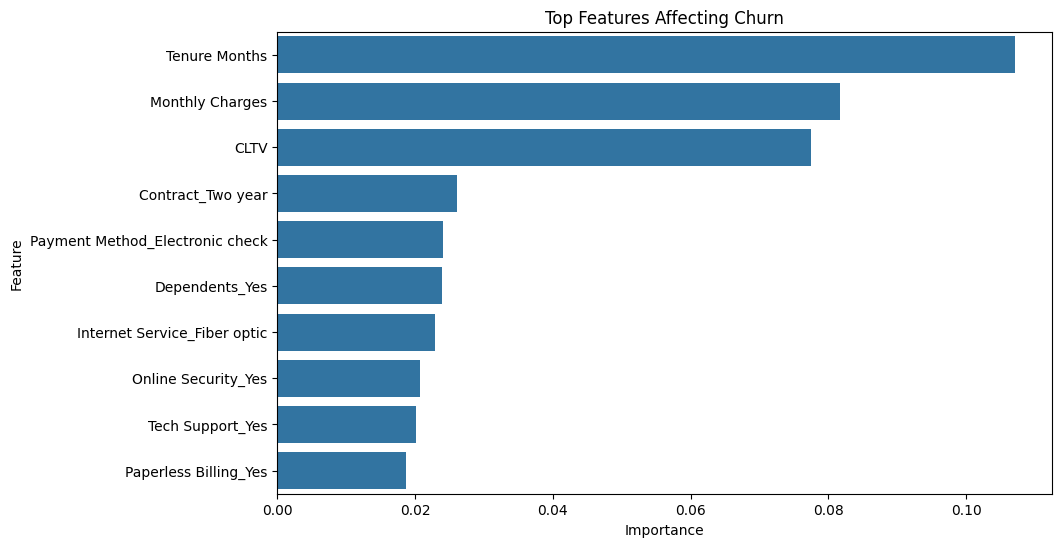

In [58]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df.head(10)
)

plt.title("Top Features Affecting Churn")

plt.show()

In [59]:
print(feature_names[:20])

['Tenure Months' 'Monthly Charges' 'CLTV' 'Gender_Male'
 'Senior Citizen_Yes' 'Partner_Yes' 'Dependents_Yes' 'Phone Service_Yes'
 'Multiple Lines_No phone service' 'Multiple Lines_Yes'
 'Internet Service_Fiber optic' 'Internet Service_No'
 'Online Security_No internet service' 'Online Security_Yes'
 'Online Backup_No internet service' 'Online Backup_Yes'
 'Device Protection_No internet service' 'Device Protection_Yes'
 'Tech Support_No internet service' 'Tech Support_Yes']


In [60]:
import pickle

pickle.dump(
    rf,
    open("churn_model.pkl", "wb")
)

In [62]:
feature_names = X.columns.tolist()

pickle.dump(
    feature_names,
    open("feature_names.pkl", "wb")
)